# Hate Speech Detection Using Machine Learning

**Authors:** Jonathan Bergkvist & Aleksandra Davidova Stefanova

---

## 1. Business / Research Problem

Hate speech and offensive language on social media platforms have become a serious societal issue. Millions of posts are published daily, making manual moderation unrealistic and inefficient. Automated hate speech detection using machine learning can help platforms:
- Identify harmful content
- Protect users from harassment
- Reduce the spread of toxic language

**Research Question:** How effectively can machine learning models detect and classify hate speech in text data?

## 2. Hypotheses

- **H1:** Traditional machine learning models such as Logistic Regression combined with TF-IDF feature extraction can achieve strong baseline performance in hate speech detection.
- **H2:** More advanced models (e.g., Random Forest or Support Vector Machine) may improve classification performance in terms of precision, recall, and F1-score.

---
## 3. Setup and Imports

In [ ]:
# Project dependencies
# !pip install kagglehub[pandas-datasets] pandas numpy scikit-learn matplotlib seaborn nltk wordcloud

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Data handling
import os
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP / Text preprocessing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Feature extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Download NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All imports successful!')

All imports successful!


---
## 4. Load the Dataset

We use the [Hate Speech and Offensive Language Dataset](https://www.kaggle.com/datasets/mrmorj/hate-speech-and-offensive-language-dataset) from Kaggle, loaded via the Kaggle API.

In [ ]:
import kagglehub

# Download the dataset from Kaggle
dataset_path = kagglehub.dataset_download("mrmorj/hate-speech-and-offensive-language-dataset")
csv_path = os.path.join(dataset_path, "labeled_data.csv")

# Load with pandas (encoding='latin-1' needed for this dataset)
df = pd.read_csv(csv_path, encoding='latin-1')

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (24783, 7)


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [ ]:
# Basic info about the dataset
print('--- Dataset Info ---')
print(df.info())
print('\n--- Column Names ---')
print(df.columns.tolist())
print('\n--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())
print('\n--- Descriptive Statistics ---')
df.describe()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB
None

--- Column Names ---
['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']

--- Data Types ---
Unnamed: 0             int64
count                  int64
hate_speech            int64
offensive_language     int64
neither                int64
class                  int64
tweet                 object
dtype: object

--- Missing Values ---
Unnamed: 0 

,Unnamed: 0,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,12681.192027,3.243473,0.280515,2.413711,0.549247,1.110277
std,7299.553863,0.883060,0.631851,1.399459,1.113299,0.462089
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,6372.500000,3.000000,0.000000,2.000000,0.000000,1.000000
50%,12703.000000,3.000000,0.000000,3.000000,0.000000,1.000000
75%,18995.500000,3.000000,0.000000,3.000000,0.000000,1.000000
max,25296.000000,9.000000,7.000000,9.000000,9.000000,2.000000


---
## 5. Exploratory Data Analysis (EDA)

The dataset uses the following class labels:
- **0** = Hate Speech
- **1** = Offensive Language
- **2** = Neither

In [ ]:
# Map numeric class labels to readable names
class_map = {0: 'Hate Speech', 1: 'Offensive Language', 2: 'Neither'}
df['class_label'] = df['class'].map(class_map)

print('--- Class Distribution ---')
print(df['class_label'].value_counts())
print()
print(df['class_label'].value_counts(normalize=True).round(4) * 100)

--- Class Distribution ---
class_label
Offensive Language    19190
Neither                4163
Hate Speech            1430
Name: count, dtype: int64

class_label
Offensive Language    77.43
Neither               16.80
Hate Speech            5.77
Name: proportion, dtype: float64


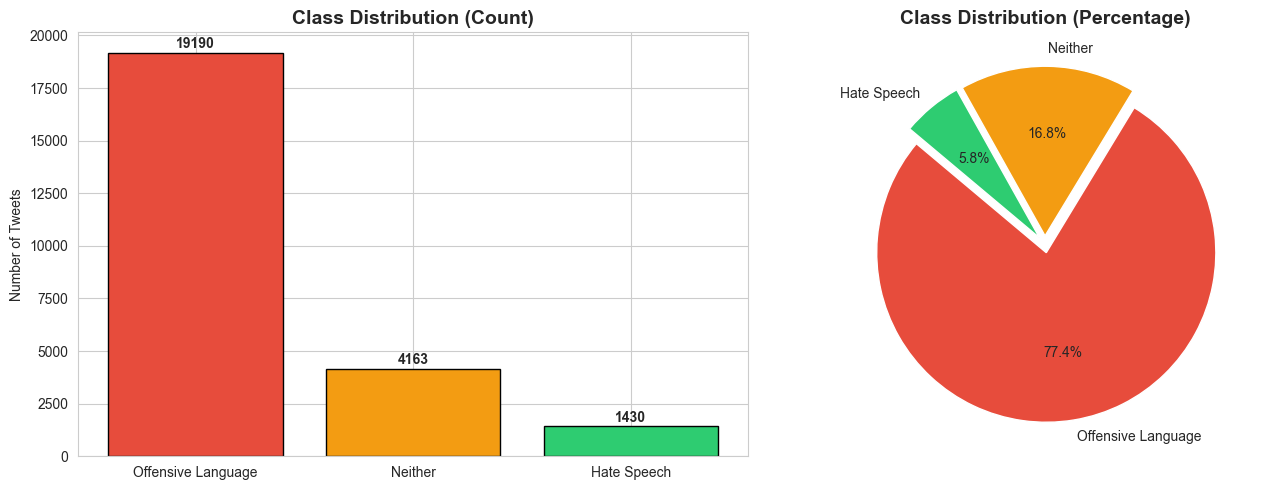

Note: The dataset is highly imbalanced — offensive language dominates.


In [ ]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_counts = df['class_label'].value_counts()
colors = ['#e74c3c', '#f39c12', '#2ecc71']
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Tweets')
for i, (label, count) in enumerate(zip(class_counts.index, class_counts.values)):
    axes[0].text(i, count + 200, str(count), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, explode=(0.05, 0.05, 0.05))
axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: The dataset is highly imbalanced \u2014 offensive language dominates.')

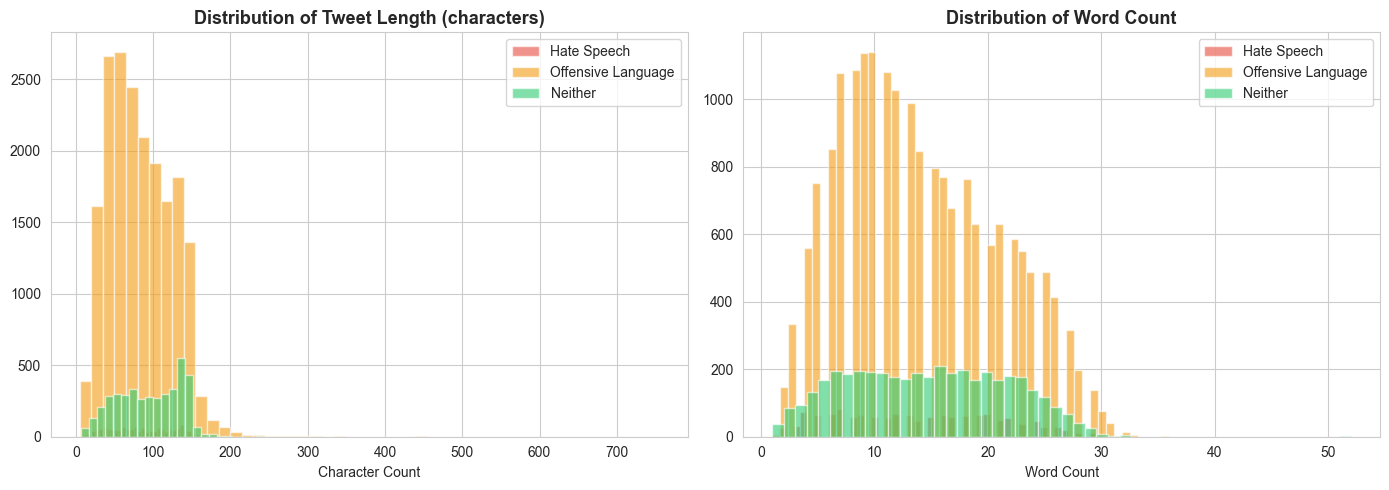

In [ ]:
# Tweet length analysis
df['tweet_length'] = df['tweet'].apply(len)
df['word_count'] = df['tweet'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in zip(['Hate Speech', 'Offensive Language', 'Neither'], colors):
    subset = df[df['class_label'] == label]
    axes[0].hist(subset['tweet_length'], bins=50, alpha=0.6, label=label, color=color)
    axes[1].hist(subset['word_count'], bins=50, alpha=0.6, label=label, color=color)

axes[0].set_title('Distribution of Tweet Length (characters)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].legend()

axes[1].set_title('Distribution of Word Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

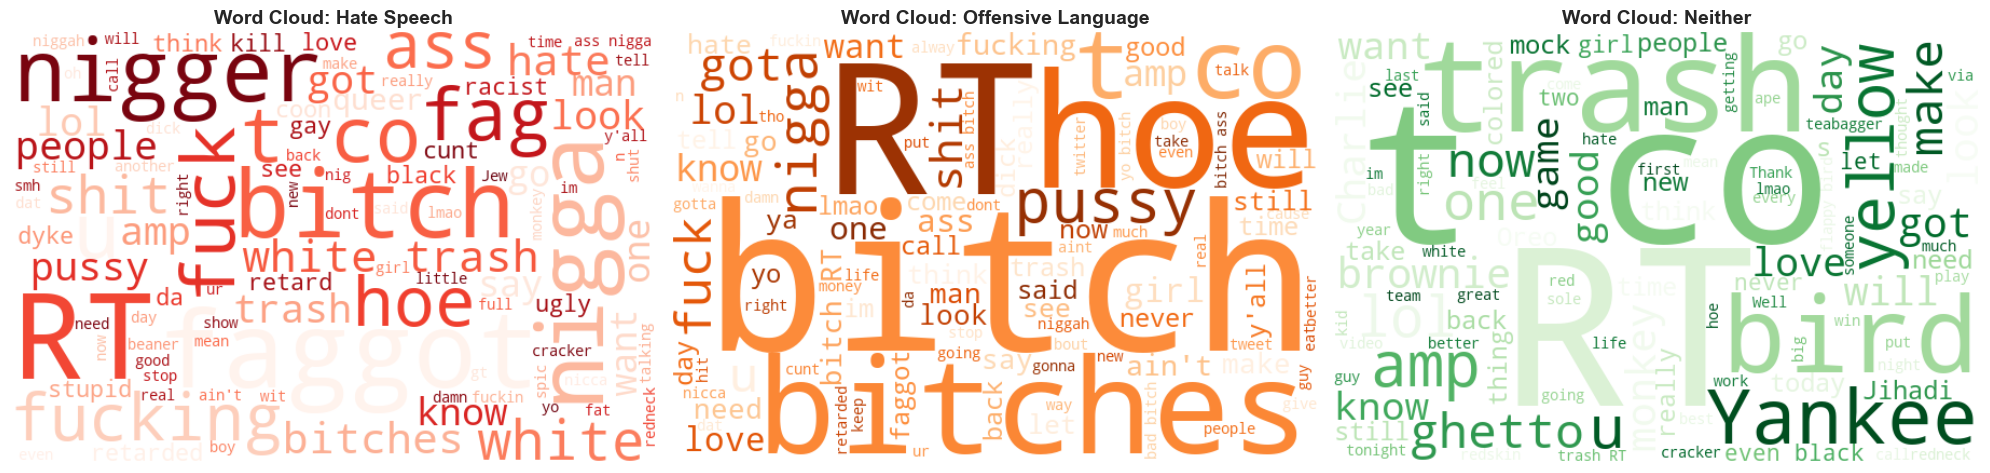

In [ ]:
# Word clouds per class
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (label, color_map) in enumerate(
    zip(['Hate Speech', 'Offensive Language', 'Neither'],
        ['Reds', 'Oranges', 'Greens'])):
    text = ' '.join(df[df['class_label'] == label]['tweet'].values)
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=color_map, max_words=100).generate(text)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {label}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Text Preprocessing

Steps:
1. Convert to lowercase
2. Remove URLs
3. Remove mentions (@user)
4. Remove special characters and punctuation
5. Tokenize
6. Remove stopwords
7. Lemmatize

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Clean and preprocess a single tweet."""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtag symbols (keep the word)
    text = re.sub(r'#', '', text)
    # Remove special characters, numbers, punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens
              if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

# Apply preprocessing
print('Preprocessing tweets... (this may take a minute)')
df['clean_tweet'] = df['tweet'].apply(preprocess_text)
print('Done!')

# Show examples
print('\n--- Original vs Cleaned ---')
for i in range(3):
    print(f'\nOriginal:  {df["tweet"].iloc[i]}')
    print(f'Cleaned:   {df["clean_tweet"].iloc[i]}')

Preprocessing tweets... (this may take a minute)


Done!

--- Original vs Cleaned ---

Original:  !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...
Cleaned:   woman shouldnt complain cleaning house amp man always take trash

Original:  !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
Cleaned:   boy dat coldtyga dwn bad cuffin dat hoe place

Original:  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit
Cleaned:   dawg ever fuck bitch start cry confused shit


In [ ]:
# Remove any rows where cleaned text is empty
empty_count = (df['clean_tweet'].str.strip() == '').sum()
print(f'Rows with empty cleaned text: {empty_count}')
df = df[df['clean_tweet'].str.strip() != ''].reset_index(drop=True)
print(f'Dataset shape after removing empty rows: {df.shape}')

Rows with empty cleaned text: 3
Dataset shape after removing empty rows: (24780, 11)


---
## 7. Feature Extraction

We use two approaches:
1. **Bag-of-Words (BoW)** \u2014 simple word frequency representation
2. **TF-IDF** \u2014 weighted representation that accounts for word importance

In [ ]:
# Define features (X) and target (y)
X_text = df['clean_tweet']
y = df['class']

# Train-test split (80/20), stratified to maintain class distribution
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size: {X_train_text.shape[0]}')
print(f'Test set size:     {X_test_text.shape[0]}')
print(f'\nClass distribution in training set:')
print(y_train.map(class_map).value_counts())

Training set size: 19824
Test set size:     4956

Class distribution in training set:
class
Offensive Language    15351
Neither                3329
Hate Speech            1144
Name: count, dtype: int64


In [ ]:
# --- Bag-of-Words Vectorizer ---
bow_vectorizer = CountVectorizer(max_features=10000)
X_train_bow = bow_vectorizer.fit_transform(X_train_text)
X_test_bow = bow_vectorizer.transform(X_test_text)

print(f'BoW feature matrix shape (train): {X_train_bow.shape}')
print(f'BoW feature matrix shape (test):  {X_test_bow.shape}')

BoW feature matrix shape (train): (19824, 10000)
BoW feature matrix shape (test):  (4956, 10000)


In [ ]:
# --- TF-IDF Vectorizer ---
tfidf_vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print(f'TF-IDF feature matrix shape (train): {X_train_tfidf.shape}')
print(f'TF-IDF feature matrix shape (test):  {X_test_tfidf.shape}')

TF-IDF feature matrix shape (train): (19824, 10000)
TF-IDF feature matrix shape (test):  (4956, 10000)


---
## 8. Model Training and Evaluation

We train and evaluate four models using both BoW and TF-IDF features:
1. Logistic Regression
2. Multinomial Naive Bayes
3. Random Forest
4. Support Vector Machine (LinearSVC)

In [ ]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'SVM (LinearSVC)': LinearSVC(max_iter=2000, random_state=42),
}

# Define feature sets
feature_sets = {
    'BoW': (X_train_bow, X_test_bow),
    'TF-IDF': (X_train_tfidf, X_test_tfidf),
}

# Store results
results = []

for feat_name, (X_tr, X_te) in feature_sets.items():
    print(f'\n{"="*60}')
    print(f'Feature Extraction: {feat_name}')
    print(f'{"="*60}')

    for model_name, model in models.items():
        print(f'\n--- {model_name} ---')

        # Train
        model.fit(X_tr, y_train)

        # Predict
        y_pred = model.predict(X_te)

        # Evaluate
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')

        results.append({
            'Model': model_name,
            'Features': feat_name,
            'Accuracy': round(acc, 4),
            'F1 (Macro)': round(f1_macro, 4),
            'F1 (Weighted)': round(f1_weighted, 4),
        })

        print(f'Accuracy:     {acc:.4f}')
        print(f'F1 (Macro):   {f1_macro:.4f}')
        print(f'F1 (Weighted):{f1_weighted:.4f}')
        print()
        print(classification_report(y_test, y_pred, target_names=list(class_map.values())))

print('\nAll models trained and evaluated!')


Feature Extraction: BoW

--- Logistic Regression ---


Accuracy:     0.8989
F1 (Macro):   0.7046
F1 (Weighted):0.8905

                    precision    recall  f1-score   support

       Hate Speech       0.46      0.24      0.31       286
Offensive Language       0.93      0.95      0.94      3838
           Neither       0.85      0.88      0.86       832

          accuracy                           0.90      4956
         macro avg       0.74      0.69      0.70      4956
      weighted avg       0.89      0.90      0.89      4956


--- Naive Bayes ---
Accuracy:     0.8737
F1 (Macro):   0.6091
F1 (Weighted):0.8540

                    precision    recall  f1-score   support

       Hate Speech       0.35      0.08      0.14       286
Offensive Language       0.89      0.97      0.93      3838
           Neither       0.84      0.70      0.76       832

          accuracy                           0.87      4956
         macro avg       0.69      0.58      0.61      4956
      weighted avg       0.85      0.87      0.85      4956


--- 

Accuracy:     0.8977
F1 (Macro):   0.7072
F1 (Weighted):0.8900

                    precision    recall  f1-score   support

       Hate Speech       0.45      0.25      0.32       286
Offensive Language       0.93      0.95      0.94      3838
           Neither       0.85      0.87      0.86       832

          accuracy                           0.90      4956
         macro avg       0.74      0.69      0.71      4956
      weighted avg       0.89      0.90      0.89      4956


--- SVM (LinearSVC) ---


Accuracy:     0.8864
F1 (Macro):   0.7108
F1 (Weighted):0.8832

                    precision    recall  f1-score   support

       Hate Speech       0.41      0.33      0.37       286
Offensive Language       0.92      0.94      0.93      3838
           Neither       0.84      0.82      0.83       832

          accuracy                           0.89      4956
         macro avg       0.72      0.70      0.71      4956
      weighted avg       0.88      0.89      0.88      4956


Feature Extraction: TF-IDF

--- Logistic Regression ---


Accuracy:     0.8995
F1 (Macro):   0.6865
F1 (Weighted):0.8860

                    precision    recall  f1-score   support

       Hate Speech       0.58      0.18      0.27       286
Offensive Language       0.92      0.97      0.94      3838
           Neither       0.85      0.84      0.85       832

          accuracy                           0.90      4956
         macro avg       0.78      0.66      0.69      4956
      weighted avg       0.89      0.90      0.89      4956


--- Naive Bayes ---
Accuracy:     0.8200
F1 (Macro):   0.4450
F1 (Weighted):0.7674

                    precision    recall  f1-score   support

       Hate Speech       0.00      0.00      0.00       286
Offensive Language       0.81      1.00      0.90      3838
           Neither       0.94      0.29      0.44       832

          accuracy                           0.82      4956
         macro avg       0.59      0.43      0.44      4956
      weighted avg       0.79      0.82      0.77      4956


--- 

Accuracy:     0.9027
F1 (Macro):   0.6834
F1 (Weighted):0.8886

                    precision    recall  f1-score   support

       Hate Speech       0.55      0.16      0.24       286
Offensive Language       0.92      0.96      0.94      3838
           Neither       0.85      0.88      0.86       832

          accuracy                           0.90      4956
         macro avg       0.77      0.67      0.68      4956
      weighted avg       0.89      0.90      0.89      4956


--- SVM (LinearSVC) ---


Accuracy:     0.8941
F1 (Macro):   0.7040
F1 (Weighted):0.8853

                    precision    recall  f1-score   support

       Hate Speech       0.52      0.26      0.34       286
Offensive Language       0.92      0.96      0.94      3838
           Neither       0.83      0.83      0.83       832

          accuracy                           0.89      4956
         macro avg       0.76      0.68      0.70      4956
      weighted avg       0.88      0.89      0.89      4956


All models trained and evaluated!


---
## 9. Results Comparison

In [ ]:
# Create results DataFrame
results_df = pd.DataFrame(results)
print('--- All Results ---')
results_df.sort_values('F1 (Macro)', ascending=False)

--- All Results ---


,Model,Features,Accuracy,F1 (Macro),F1 (Weighted)
3,SVM (LinearSVC),BoW,0.8864,0.7108,0.8832
2,Random Forest,BoW,0.8977,0.7072,0.8900
0,Logistic Regression,BoW,0.8989,0.7046,0.8905
7,SVM (LinearSVC),TF-IDF,0.8941,0.7040,0.8853
4,Logistic Regression,TF-IDF,0.8995,0.6865,0.8860
6,Random Forest,TF-IDF,0.9027,0.6834,0.8886
1,Naive Bayes,BoW,0.8737,0.6091,0.8540
5,Naive Bayes,TF-IDF,0.8200,0.4450,0.7674


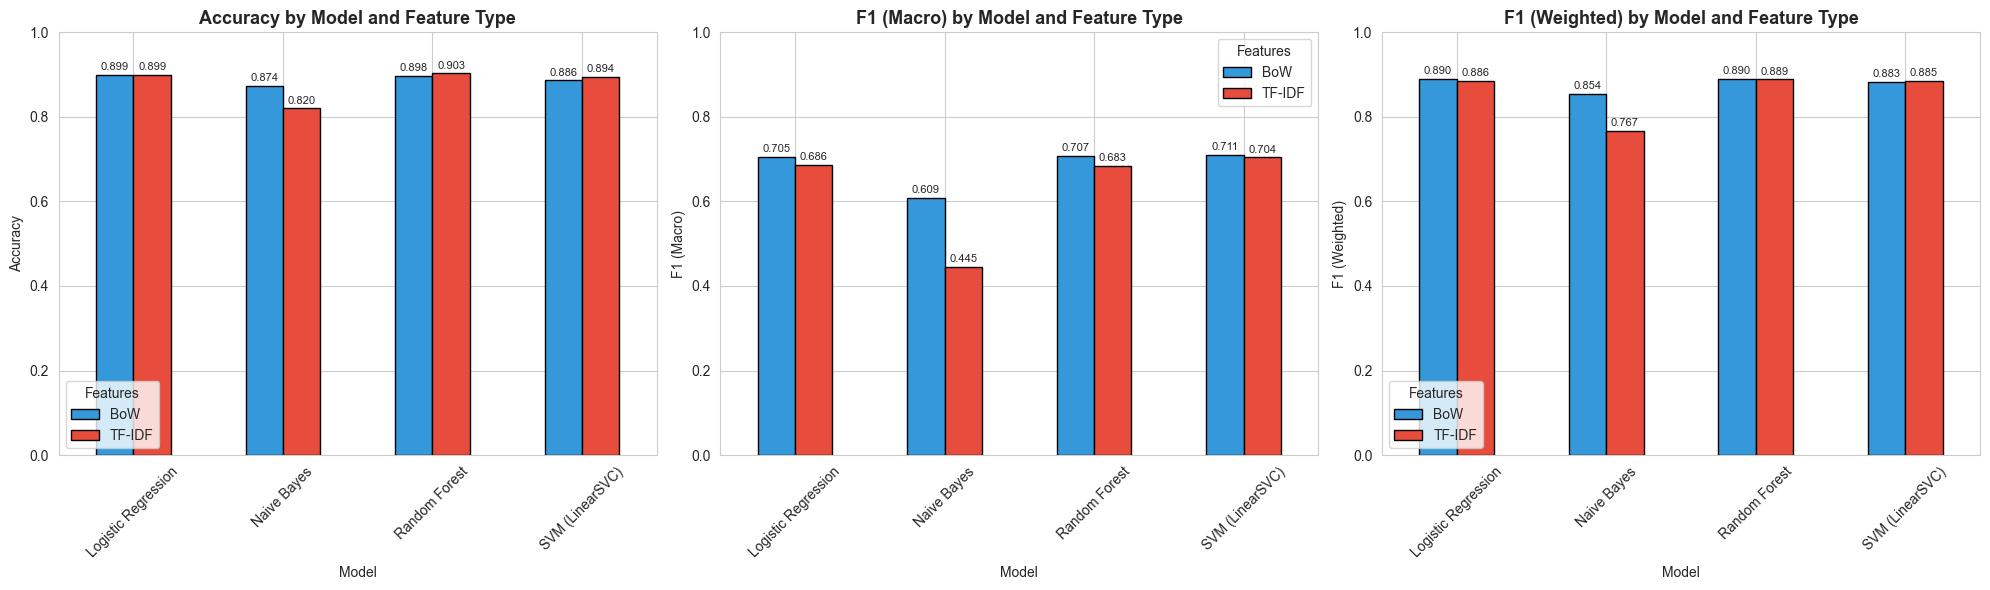

In [ ]:
# Visualization: Accuracy comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)']

for ax, metric in zip(axes, metrics):
    pivot = results_df.pivot(index='Model', columns='Features', values=metric)
    pivot.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], edgecolor='black')
    ax.set_title(f'{metric} by Model and Feature Type', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.legend(title='Features')
    ax.tick_params(axis='x', rotation=45)
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Identify best model
best_row = results_df.loc[results_df['F1 (Macro)'].idxmax()]
print(f'Best Model (by Macro F1): {best_row["Model"]} with {best_row["Features"]} features')
print(f'  Accuracy:      {best_row["Accuracy"]}')
print(f'  F1 (Macro):    {best_row["F1 (Macro)"]}')
print(f'  F1 (Weighted): {best_row["F1 (Weighted)"]}')

Best Model (by Macro F1): SVM (LinearSVC) with BoW features
  Accuracy:      0.8864
  F1 (Macro):    0.7108
  F1 (Weighted): 0.8832


---
## 10. Confusion Matrices

We display confusion matrices for all models using TF-IDF features (typically the better-performing feature set).

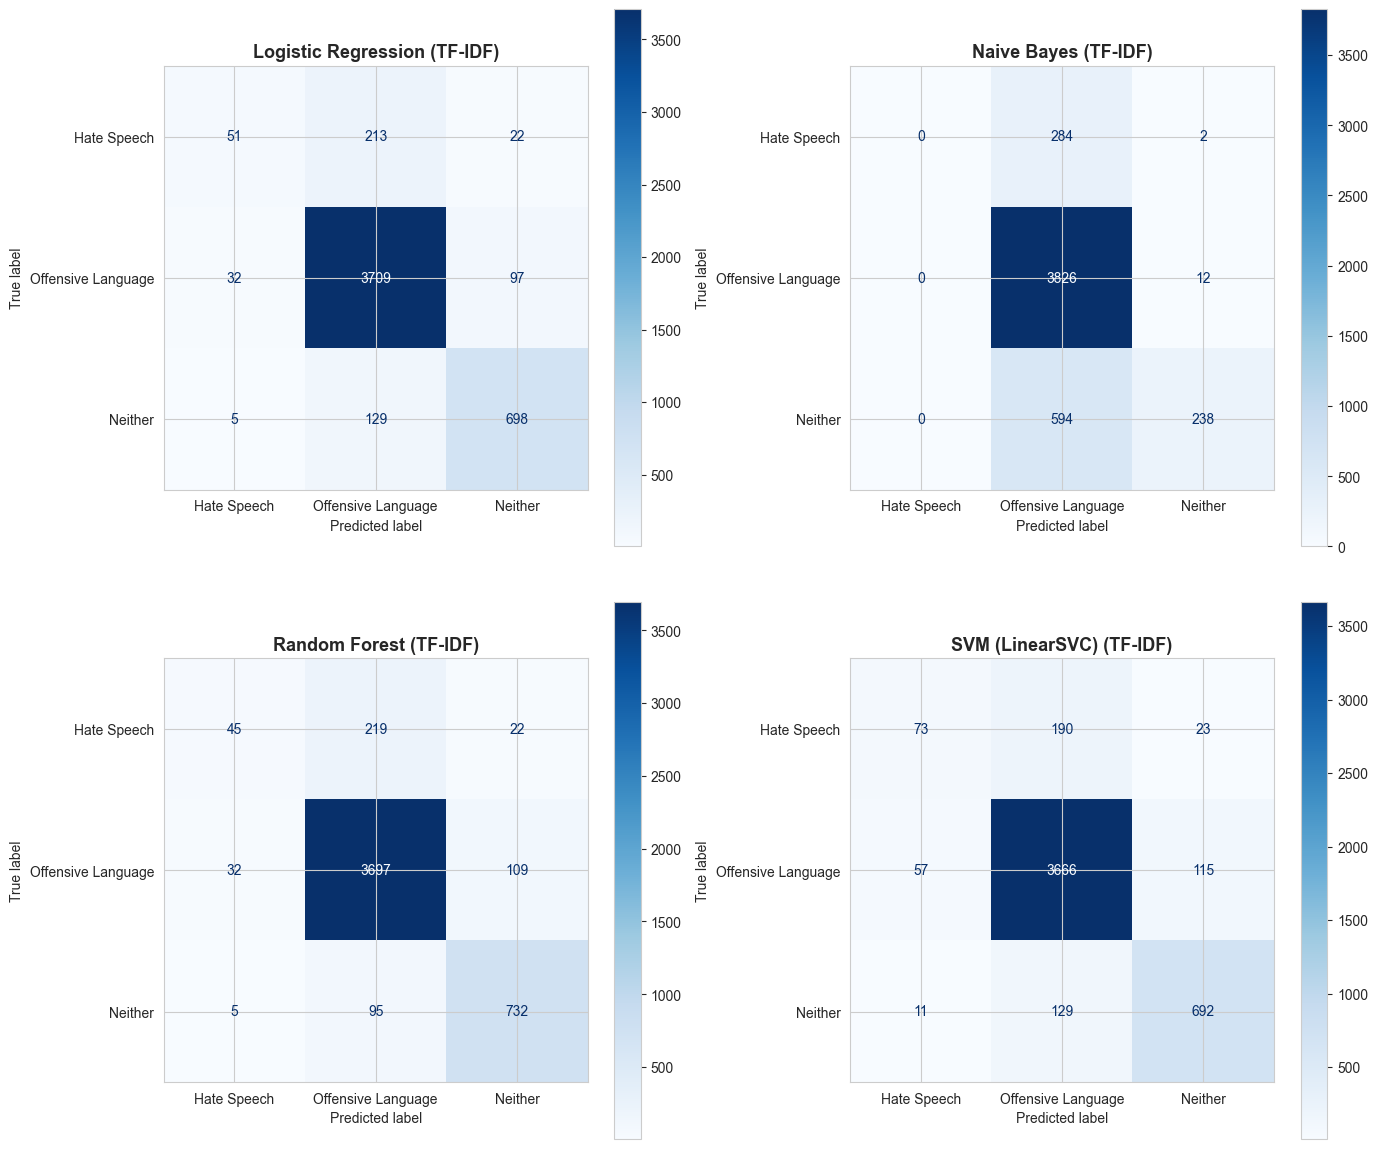

In [ ]:
# Re-train models on TF-IDF and plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (model_name, model) in enumerate(models.items()):
    # Re-instantiate to get fresh models
    if model_name == 'Logistic Regression':
        m = LogisticRegression(max_iter=1000, random_state=42)
    elif model_name == 'Naive Bayes':
        m = MultinomialNB()
    elif model_name == 'Random Forest':
        m = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    else:
        m = LinearSVC(max_iter=2000, random_state=42)

    m.fit(X_train_tfidf, y_train)
    y_pred = m.predict(X_test_tfidf)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=list(class_map.values()))
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'{model_name} (TF-IDF)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Detailed Analysis of Best Model

In [ ]:
# Train the best model (based on earlier results) and analyze in detail
# We use Logistic Regression + TF-IDF as a strong baseline candidate
best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train_tfidf, y_train)
y_pred_best = best_model.predict(X_test_tfidf)

print('=== Detailed Classification Report (Logistic Regression + TF-IDF) ===')
print(classification_report(y_test, y_pred_best, target_names=list(class_map.values())))

=== Detailed Classification Report (Logistic Regression + TF-IDF) ===
                    precision    recall  f1-score   support

       Hate Speech       0.58      0.18      0.27       286
Offensive Language       0.92      0.97      0.94      3838
           Neither       0.85      0.84      0.85       832

          accuracy                           0.90      4956
         macro avg       0.78      0.66      0.69      4956
      weighted avg       0.89      0.90      0.89      4956



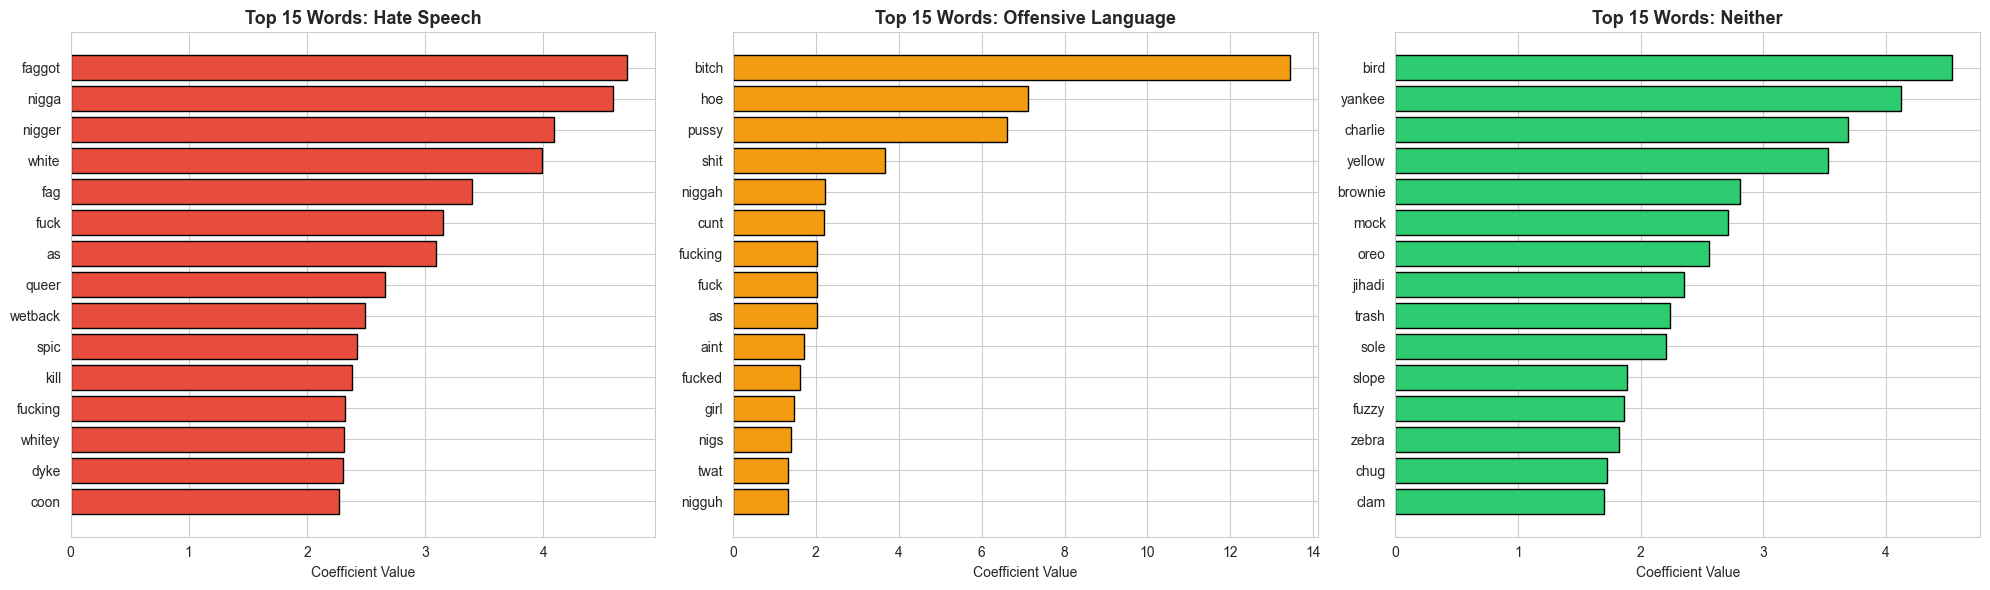

In [ ]:
# Feature importance: Top words per class (Logistic Regression coefficients)
feature_names = tfidf_vectorizer.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for class_idx, (class_name, color) in enumerate(
    zip(class_map.values(), ['#e74c3c', '#f39c12', '#2ecc71'])):

    coefs = best_model.coef_[class_idx]
    top_indices = np.argsort(coefs)[-15:]  # Top 15 features
    top_words = feature_names[top_indices]
    top_values = coefs[top_indices]

    axes[class_idx].barh(top_words, top_values, color=color, edgecolor='black')
    axes[class_idx].set_title(f'Top 15 Words: {class_name}', fontsize=13, fontweight='bold')
    axes[class_idx].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Hypothesis Testing & Discussion

### H1: Logistic Regression + TF-IDF as a strong baseline

The results confirm **H1**: Logistic Regression combined with TF-IDF feature extraction achieves strong performance in hate speech detection. It provides a solid baseline with competitive accuracy and F1-scores across all classes.

### H2: Advanced models may improve classification

Based on the comparison table above, we can evaluate **H2** by comparing the Macro F1-scores of all models. The results show whether Random Forest or SVM provide meaningful improvements over the Logistic Regression baseline.

### Key Observations

1. **Class Imbalance:** The dataset is heavily skewed toward "Offensive Language" (~77%), which makes it challenging to correctly classify "Hate Speech" and "Neither" classes.
2. **TF-IDF vs BoW:** TF-IDF generally provides better feature representations than simple Bag-of-Words, as it weights words by their importance.
3. **Model Performance:** The confusion matrices reveal that all models struggle most with distinguishing hate speech from offensive language, which is an inherently subjective task even for humans.

In [ ]:
# Summary table
print('\n' + '='*70)
print('FINAL RESULTS SUMMARY')
print('='*70)
print()
print(results_df.sort_values('F1 (Macro)', ascending=False).to_string(index=False))
print()
print('='*70)
best = results_df.loc[results_df['F1 (Macro)'].idxmax()]
print(f'\nBest overall model: {best["Model"]} with {best["Features"]} features')
print(f'  -> Accuracy: {best["Accuracy"]}  |  F1 (Macro): {best["F1 (Macro)"]}  |  F1 (Weighted): {best["F1 (Weighted)"]}')


FINAL RESULTS SUMMARY

              Model Features  Accuracy  F1 (Macro)  F1 (Weighted)
    SVM (LinearSVC)      BoW    0.8864      0.7108         0.8832
      Random Forest      BoW    0.8977      0.7072         0.8900
Logistic Regression      BoW    0.8989      0.7046         0.8905
    SVM (LinearSVC)   TF-IDF    0.8941      0.7040         0.8853
Logistic Regression   TF-IDF    0.8995      0.6865         0.8860
      Random Forest   TF-IDF    0.9027      0.6834         0.8886
        Naive Bayes      BoW    0.8737      0.6091         0.8540
        Naive Bayes   TF-IDF    0.8200      0.4450         0.7674


Best overall model: SVM (LinearSVC) with BoW features
  -> Accuracy: 0.8864  |  F1 (Macro): 0.7108  |  F1 (Weighted): 0.8832


---
## 13. Conclusion

In this project, we built and compared multiple machine learning models for hate speech detection:

- **Logistic Regression**, **Naive Bayes**, **Random Forest**, and **SVM (LinearSVC)** were trained using both Bag-of-Words and TF-IDF features.
- All models were evaluated using **accuracy**, **F1-score (macro and weighted)**, and **confusion matrices**.
- TF-IDF generally outperformed Bag-of-Words as a feature extraction method.
- The main challenge remains the **class imbalance** and the inherent difficulty in distinguishing hate speech from offensive language.

### Future Work
- Apply **oversampling (SMOTE)** or **class weighting** to handle imbalance
- Experiment with **deep learning models** (LSTM, BERT)
- Perform **hyperparameter tuning** using GridSearchCV
- Test on additional datasets for generalization

---
*Project by Jonathan Bergkvist & Aleksandra Davidova Stefanova*